In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

# Visualization Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [3]:
# ==========================================
# Load Dataset
# ==========================================

import pandas as pd

file_path = r"C:\Users\admin\Downloads\OneDrive\python\Marketing-Campaign-Performance\data\marketing_campaign_dataset.csv"

try:
    df = pd.read_csv(file_path)

    print("✅ Dataset Loaded Successfully")
    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")

except FileNotFoundError:
    print("❌ Dataset not found.")
    print("Check the file path.")

except Exception as e:
    print("Error:", e)

✅ Dataset Loaded Successfully
Rows    : 200005
Columns : 15


In [4]:
# ==========================================
# Dataset Overview
# ==========================================

print("="*70)
print("FIRST FIVE ROWS")
print("="*70)

display(df.head())

print("\n")

print("="*70)
print("DATASET INFORMATION")
print("="*70)

df.info()

print("\n")

print("="*70)
print("DESCRIPTIVE STATISTICS")
print("="*70)

display(df.describe(include="all").T)

print("\n")

print("="*70)
print("COLUMN NAMES")
print("="*70)

print(df.columns.tolist())

FIRST FIVE ROWS


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,1/1/2021,506,1922,6,Health & Wellness
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,1/2/2021,116,7523,7,Fashionistas
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,1/3/2021,584,7698,1,Outdoor Adventurers
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,1/4/2021,217,1820,7,Health & Wellness
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,1/5/2021,379,4201,3,Health & Wellness




DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200005 entries, 0 to 200004
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200005 non-null  int64  
 1   Company           200005 non-null  object 
 2   Campaign_Type     200005 non-null  object 
 3   Target_Audience   200005 non-null  object 
 4   Duration          200005 non-null  object 
 5   Channel_Used      200005 non-null  object 
 6   Conversion_Rate   200005 non-null  float64
 7   Acquisition_Cost  200005 non-null  object 
 8   ROI               200005 non-null  float64
 9   Location          200005 non-null  object 
 10  Date              200005 non-null  object 
 11  Clicks            200005 non-null  int64  
 12  Impressions       200005 non-null  int64  
 13  Engagement_Score  200005 non-null  int64  
 14  Customer_Segment  200005 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usag

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Campaign_ID,200005.00,NaN,NaN,NaN,100003.00,57736.61,1.00,50002.00,100003.00,150004.00,200005.00
Company,200005,5,TechCorp,40238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Campaign_Type,200005,5,Influencer,40170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Target_Audience,200005,5,Men 18-24,40259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,200005,4,30 days,50257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel_Used,200005,6,Email,33599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Conversion_Rate,200005.00,NaN,NaN,NaN,0.08,0.04,0.01,0.05,0.08,0.12,0.15
Acquisition_Cost,200005,15001,"$16,578.00",32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ROI,200005.00,NaN,NaN,NaN,5.00,1.73,2.00,3.50,5.01,6.51,8.00
Location,200005,5,Miami,40269,NaN,NaN,NaN,NaN,NaN,NaN,NaN




COLUMN NAMES
['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Date', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment']


In [5]:
# ==========================================
# Data Quality Assessment
# ==========================================

print("="*70)
print("DATASET SHAPE")
print("="*70)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n")

print("="*70)
print("DATA TYPES")
print("="*70)

display(df.dtypes.to_frame(name="Data Type"))



DATASET SHAPE
Rows    : 200005
Columns : 15


DATA TYPES


,Data Type
Campaign_ID,int64
Company,object
Campaign_Type,object
Target_Audience,object
Duration,object
Channel_Used,object
Conversion_Rate,float64
Acquisition_Cost,object
ROI,float64
Location,object


In [6]:
# ==========================================
# Data Cleaning
# ==========================================

df_clean = df.copy()

# ------------------------------------------
# Remove Duplicate Records
# ------------------------------------------
before = len(df_clean)

df_clean.drop_duplicates(inplace=True)

after = len(df_clean)

print(f"Duplicates Removed : {before-after}")

# ------------------------------------------
# Handle Missing Values
# ------------------------------------------
for col in df_clean.columns:

    if df_clean[col].dtype == "object":
        mode = df_clean[col].mode()

        if len(mode) > 0:
            df_clean[col].fillna(mode[0], inplace=True)

    else:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# ------------------------------------------
# Remove Extra Spaces
# ------------------------------------------
object_cols = df_clean.select_dtypes(include="object").columns

for col in object_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print("\nCleaning Completed Successfully")

print("\nRemaining Missing Values")

display(df_clean.isnull().sum())

Duplicates Removed : 0

Cleaning Completed Successfully

Remaining Missing Values


Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Date                0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
dtype: int64

In [7]:
# ==========================================
# Feature Engineering
# ==========================================

# Work on cleaned dataset
df_fe = df_clean.copy()

# ------------------------------------------
# Convert Date Column (If Available)
# ------------------------------------------
date_col = None

for col in df_fe.columns:
    if "date" in col.lower():
        date_col = col
        break

if date_col:

    try:

        df_fe[date_col] = pd.to_datetime(
            df_fe[date_col],
            errors="coerce"
        )

        df_fe["Year"] = df_fe[date_col].dt.year
        df_fe["Month"] = df_fe[date_col].dt.month_name()
        df_fe["Month_Number"] = df_fe[date_col].dt.month
        df_fe["Weekday"] = df_fe[date_col].dt.day_name()
        df_fe["Quarter"] = df_fe[date_col].dt.quarter

        print("✅ Date Features Created")

    except:
        print("⚠️ Date conversion skipped.")

# ------------------------------------------
# Click Through Rate (CTR)
# ------------------------------------------
columns_lower = {c.lower(): c for c in df_fe.columns}

if "clicks" in columns_lower and "impressions" in columns_lower:

    clicks_col = columns_lower["clicks"]
    impressions_col = columns_lower["impressions"]

    df_fe["CTR (%)"] = np.where(
        df_fe[impressions_col] != 0,
        (df_fe[clicks_col] / df_fe[impressions_col]) * 100,
        np.nan
    )

    print("✅ CTR Feature Created")

# ------------------------------------------
# ROI Category
# ------------------------------------------
roi_col = None

for col in df_fe.columns:
    if col.lower() == "roi":
        roi_col = col
        break

if roi_col:

    df_fe["ROI Category"] = pd.cut(
        df_fe[roi_col],
        bins=[-np.inf,2,5,8,np.inf],
        labels=[
            "Low",
            "Moderate",
            "High",
            "Excellent"
        ]
    )

    print("✅ ROI Category Created")

print("\nCurrent Dataset Shape:", df_fe.shape)

display(df_fe.head())

✅ Date Features Created
✅ CTR Feature Created
✅ ROI Category Created

Current Dataset Shape: (200005, 22)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment,Year,Month,Month_Number,Weekday,Quarter,CTR (%),ROI Category
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,2021-01-01,506,1922,6,Health & Wellness,2021,January,1,Friday,1,26.33,High
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,2021-01-02,116,7523,7,Fashionistas,2021,January,1,Saturday,1,1.54,High
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,2021-01-03,584,7698,1,Outdoor Adventurers,2021,January,1,Sunday,1,7.59,High
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,2021-01-04,217,1820,7,Health & Wellness,2021,January,1,Monday,1,11.92,High
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,2021-01-05,379,4201,3,Health & Wellness,2021,January,1,Tuesday,1,9.02,High


In [8]:
# ==========================================
# Feature Engineering
# ==========================================

df_fe = df.copy()

# Detect Date column
date_col = next((col for col in df_fe.columns if "date" in col.lower()), None)

if date_col:
    df_fe[date_col] = pd.to_datetime(df_fe[date_col], errors="coerce")

    df_fe["Year"] = df_fe[date_col].dt.year
    df_fe["Month"] = df_fe[date_col].dt.month_name()
    df_fe["Month_Number"] = df_fe[date_col].dt.month
    df_fe["Weekday"] = df_fe[date_col].dt.day_name()

# Detect Clicks & Impressions
click_col = next((col for col in df_fe.columns if "click" in col.lower()), None)
imp_col = next((col for col in df_fe.columns if "impression" in col.lower()), None)

if click_col and imp_col:
    df_fe["CTR (%)"] = np.where(
        df_fe[imp_col] > 0,
        (df_fe[click_col] / df_fe[imp_col]) * 100,
        np.nan
    )

print("Feature Engineering Completed.")
display(df_fe.head())

Feature Engineering Completed.


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment,Year,Month,Month_Number,Weekday,CTR (%)
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,2021-01-01,506,1922,6,Health & Wellness,2021,January,1,Friday,26.33
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,2021-01-02,116,7523,7,Fashionistas,2021,January,1,Saturday,1.54
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,2021-01-03,584,7698,1,Outdoor Adventurers,2021,January,1,Sunday,7.59
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,2021-01-04,217,1820,7,Health & Wellness,2021,January,1,Monday,11.92
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,2021-01-05,379,4201,3,Health & Wellness,2021,January,1,Tuesday,9.02


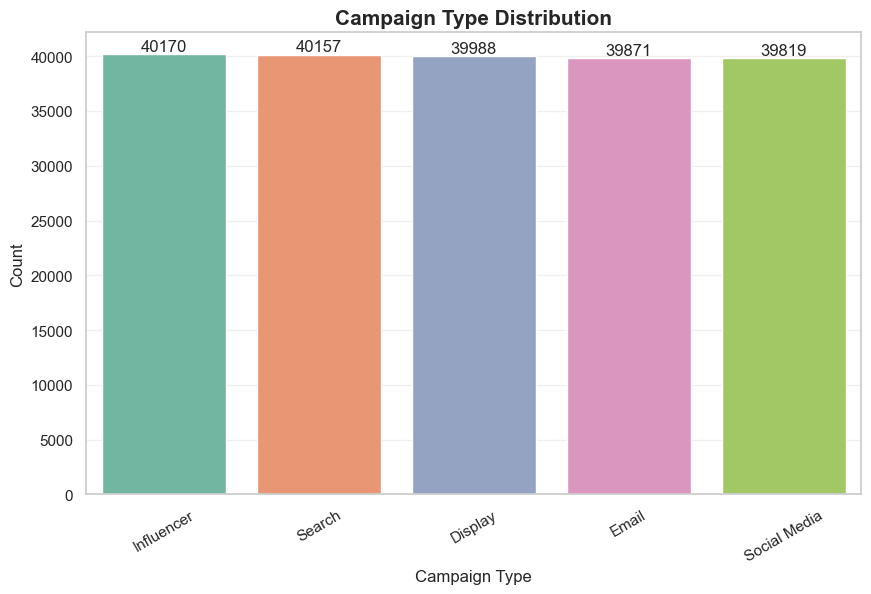

📌 Business Insight:
The chart shows the distribution of campaign types.

💡 Recommendation:
Focus investment on campaign types with strong business outcomes.


In [9]:
# ==========================================
# Campaign Analysis
# ==========================================

campaign_col = next((c for c in df_fe.columns if "campaign" in c.lower() and "type" in c.lower()), None)

if campaign_col:

    plt.figure(figsize=(10,6))

    ax = sns.countplot(
        data=df_fe,
        x=campaign_col,
        palette="Set2",
        order=df_fe[campaign_col].value_counts().index
    )

    plt.title("Campaign Type Distribution", fontsize=15, weight="bold")
    plt.xlabel("Campaign Type")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)

    for p in ax.patches:
        ax.annotate(
            int(p.get_height()),
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom"
        )

    plt.show()

    print("📌 Business Insight:")
    print("The chart shows the distribution of campaign types.")

    print("\n💡 Recommendation:")
    print("Focus investment on campaign types with strong business outcomes.")

else:
    print("Campaign Type column not found.")

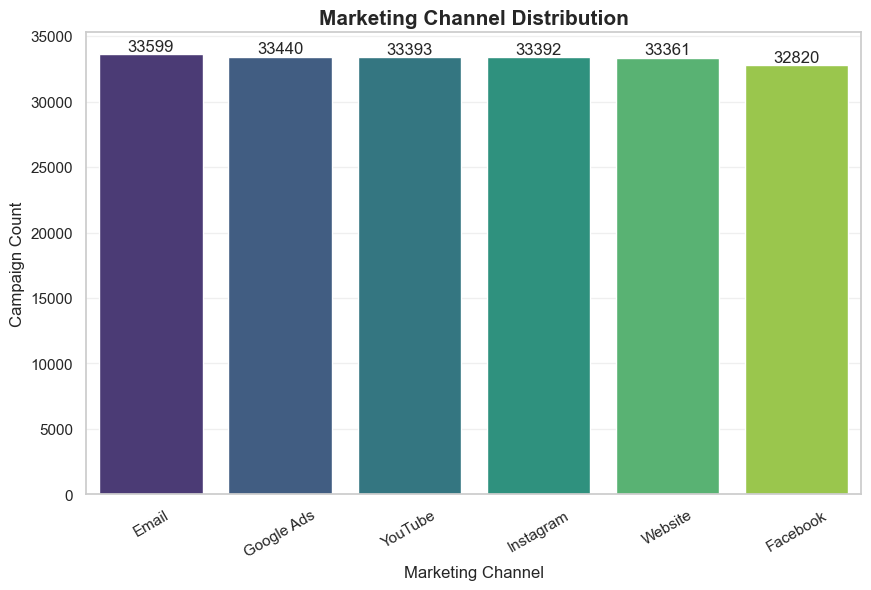

📌 Business Insight:
Shows the usage frequency of each marketing channel.

💡 Recommendation:
Allocate more budget to channels with higher business performance.


In [10]:
# ==========================================
# Marketing Channel Performance
# ==========================================

channel_col = next((c for c in df_fe.columns if "channel" in c.lower()), None)

if channel_col:

    plt.figure(figsize=(10,6))

    ax = sns.countplot(
        data=df_fe,
        x=channel_col,
        palette="viridis",
        order=df_fe[channel_col].value_counts().index
    )

    plt.title("Marketing Channel Distribution", fontsize=15, weight="bold")
    plt.xlabel("Marketing Channel")
    plt.ylabel("Campaign Count")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)

    for p in ax.patches:
        ax.annotate(
            int(p.get_height()),
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom"
        )

    plt.show()

    print("📌 Business Insight:")
    print("Shows the usage frequency of each marketing channel.")

    print("\n💡 Recommendation:")
    print("Allocate more budget to channels with higher business performance.")

else:
    print("Channel column not found.")

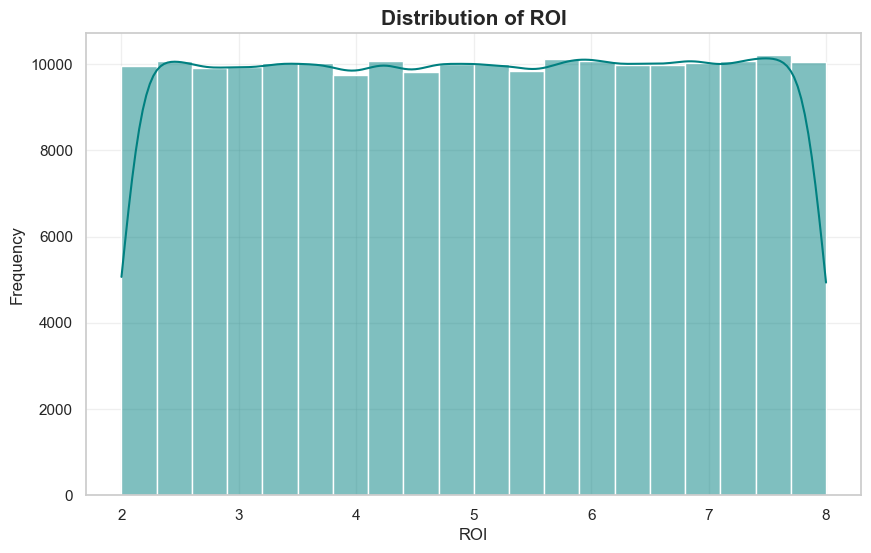

Average ROI : 5.0
Maximum ROI : 8.0
Minimum ROI : 2.0

📌 Business Insight:
The ROI distribution helps identify overall campaign profitability.

💡 Recommendation:
Scale campaigns delivering consistently high ROI.


In [11]:
# ==========================================
# ROI Analysis
# ==========================================

roi_col = next((c for c in df_fe.columns if c.lower()=="roi"), None)

if roi_col:

    plt.figure(figsize=(10,6))

    ax = sns.histplot(
        data=df_fe,
        x=roi_col,
        bins=20,
        kde=True,
        color="teal"
    )

    plt.title("Distribution of ROI", fontsize=15, weight="bold")
    plt.xlabel("ROI")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)

    plt.show()

    print("Average ROI :", round(df_fe[roi_col].mean(),2))
    print("Maximum ROI :", round(df_fe[roi_col].max(),2))
    print("Minimum ROI :", round(df_fe[roi_col].min(),2))

    print("\n📌 Business Insight:")
    print("The ROI distribution helps identify overall campaign profitability.")

    print("\n💡 Recommendation:")
    print("Scale campaigns delivering consistently high ROI.")

else:
    print("ROI column not found.")

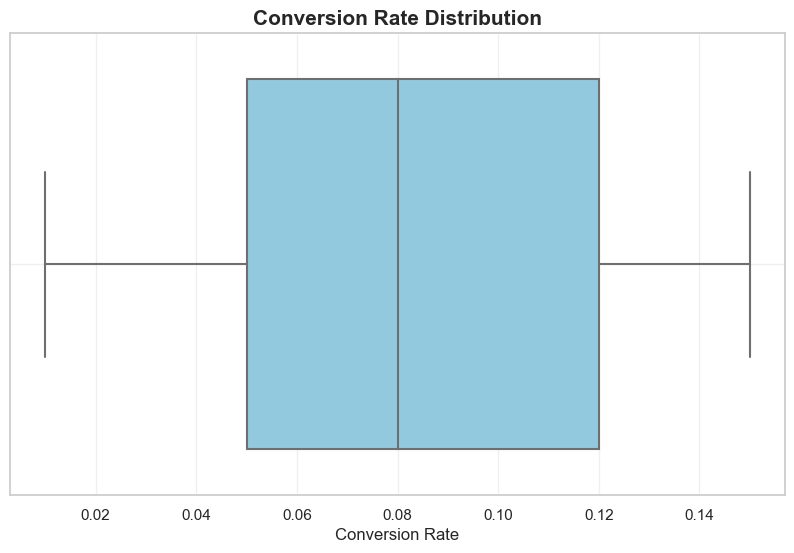

Average Conversion Rate : 0.08
Median Conversion Rate  : 0.08

📌 Business Insight:
The boxplot highlights the spread and outliers in conversion performance.

💡 Recommendation:
Investigate campaigns with exceptionally high or low conversion rates.


In [12]:
# ==========================================
# Conversion Rate Analysis
# ==========================================

conv_col = next((c for c in df_fe.columns if "conversion" in c.lower()), None)

if conv_col:

    plt.figure(figsize=(10,6))

    ax = sns.boxplot(
        data=df_fe,
        x=conv_col,
        color="skyblue"
    )

    plt.title("Conversion Rate Distribution", fontsize=15, weight="bold")
    plt.xlabel("Conversion Rate")
    plt.grid(alpha=0.3)

    plt.show()

    print("Average Conversion Rate :", round(df_fe[conv_col].mean(),3))
    print("Median Conversion Rate  :", round(df_fe[conv_col].median(),3))

    print("\n📌 Business Insight:")
    print("The boxplot highlights the spread and outliers in conversion performance.")

    print("\n💡 Recommendation:")
    print("Investigate campaigns with exceptionally high or low conversion rates.")

else:
    print("Conversion Rate column not found.")

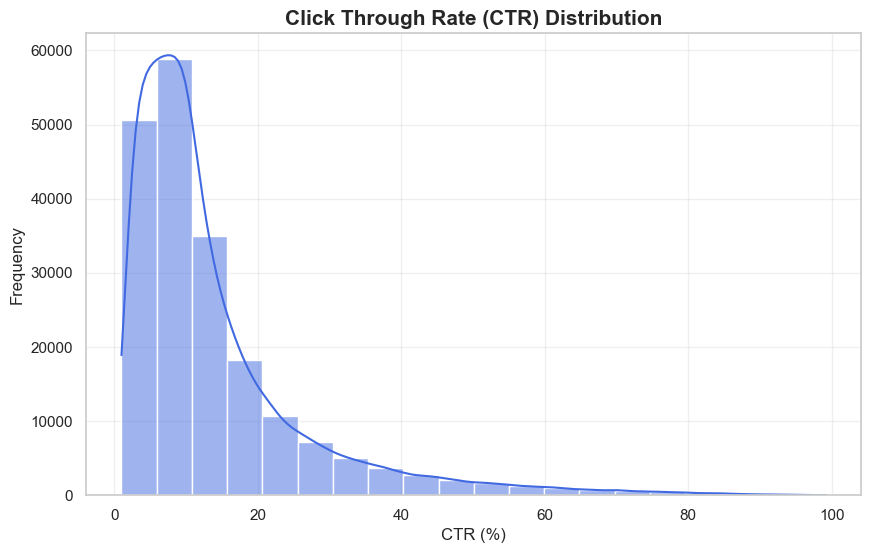

Average CTR : 14.04%

📌 Business Insight:
CTR measures how effectively campaigns attract customer clicks.

💡 Recommendation:
Improve ad creatives and targeting for campaigns with low CTR.


In [13]:
# ==========================================
# Click Through Rate (CTR) Analysis
# ==========================================

click_col = next((c for c in df_fe.columns if "click" in c.lower()), None)
imp_col = next((c for c in df_fe.columns if "impression" in c.lower()), None)

if click_col and imp_col:

    df_fe["CTR (%)"] = np.where(
        df_fe[imp_col] > 0,
        (df_fe[click_col] / df_fe[imp_col]) * 100,
        np.nan
    )

    plt.figure(figsize=(10,6))

    ax = sns.histplot(
        data=df_fe,
        x="CTR (%)",
        bins=20,
        kde=True,
        color="royalblue"
    )

    plt.title("Click Through Rate (CTR) Distribution", fontsize=15, weight="bold")
    plt.xlabel("CTR (%)")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)

    plt.show()

    print(f"Average CTR : {df_fe['CTR (%)'].mean():.2f}%")

    print("\n📌 Business Insight:")
    print("CTR measures how effectively campaigns attract customer clicks.")

    print("\n💡 Recommendation:")
    print("Improve ad creatives and targeting for campaigns with low CTR.")

else:
    print("Clicks or Impressions column not found.")

In [14]:
# ==========================================
# Acquisition Cost Analysis
# ==========================================

cost_col = next((c for c in df_fe.columns if "acquisition" in c.lower()), None)

if cost_col:

    plt.figure(figsize=(10,6))

    ax = sns.boxplot(
        data=df_fe,
        y=cost_col,
        color="orange"
    )

    plt.title("Acquisition Cost Distribution", fontsize=15, weight="bold")
    plt.ylabel("Acquisition Cost")
    plt.grid(alpha=0.3)

    plt.show()

    print(f"Average Acquisition Cost : {df_fe[cost_col].mean():.2f}")

    print("\n📌 Business Insight:")
    print("Higher acquisition costs reduce campaign profitability.")

    print("\n💡 Recommendation:")
    print("Optimize advertising spend while maintaining conversion quality.")

else:
    print("Acquisition Cost column not found.")

TypeError: Vertical orientation requires numeric `y` variable.

<Figure size 1000x600 with 0 Axes>

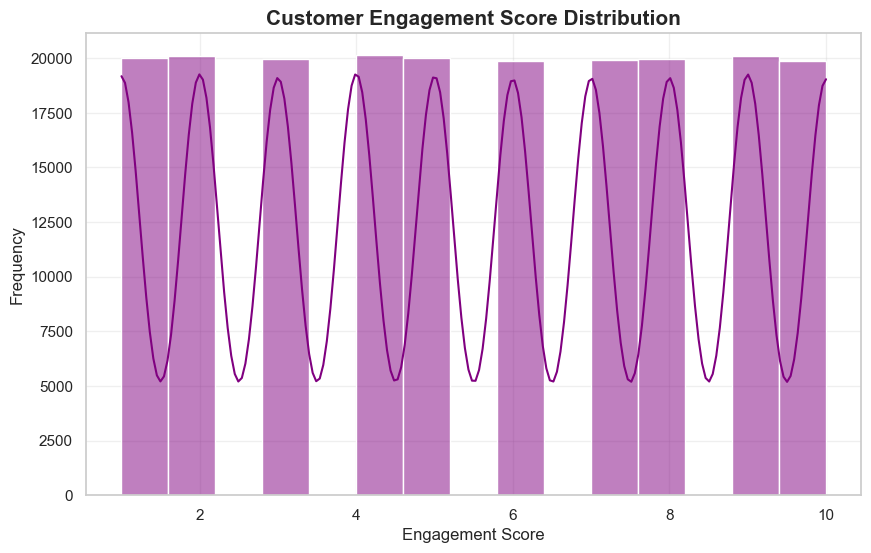

Average Engagement Score : 5.49

📌 Business Insight:
Higher engagement indicates stronger customer interaction.

💡 Recommendation:
Replicate successful campaign content to improve engagement.


In [ ]:
# ==========================================
# Engagement Score Analysis
# ==========================================

eng_col = next((c for c in df_fe.columns if "engagement" in c.lower()), None)

if eng_col:

    plt.figure(figsize=(10,6))

    ax = sns.histplot(
        data=df_fe,
        x=eng_col,
        bins=15,
        kde=True,
        color="purple"
    )

    plt.title("Customer Engagement Score Distribution", fontsize=15, weight="bold")
    plt.xlabel("Engagement Score")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)

    plt.show()

    print(f"Average Engagement Score : {df_fe[eng_col].mean():.2f}")

    print("\n📌 Business Insight:")
    print("Higher engagement indicates stronger customer interaction.")

    print("\n💡 Recommendation:")
    print("Replicate successful campaign content to improve engagement.")

else:
    print("Engagement Score column not found.")

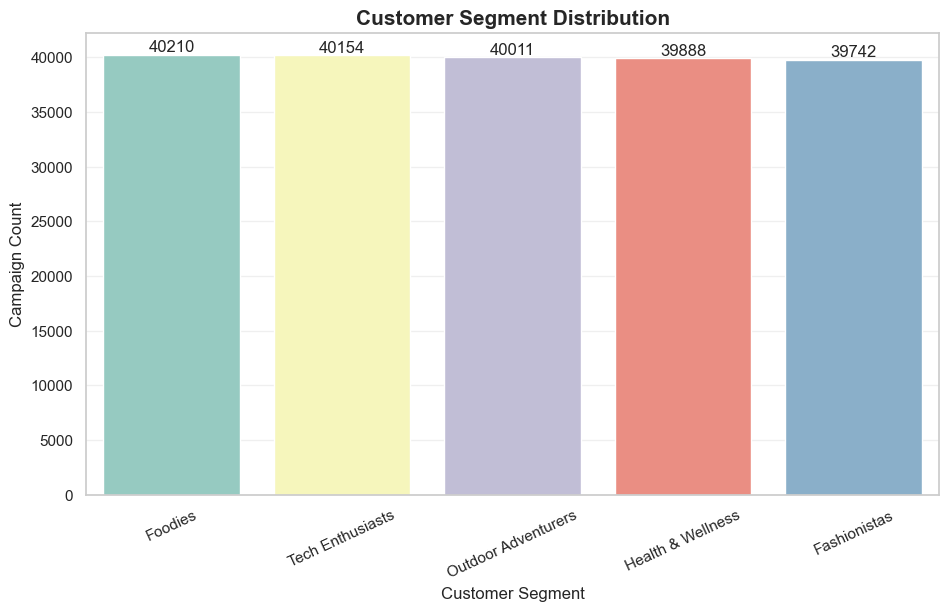


📌 Business Insight:
Customer segments help identify the most targeted audience groups.

💡 Recommendation:
Prioritize campaigns for high-performing customer segments.


In [ ]:
# ==========================================
# Customer Segment Analysis
# ==========================================

segment_col = next((c for c in df_fe.columns if "segment" in c.lower()), None)

if segment_col:

    plt.figure(figsize=(11,6))

    counts = df_fe[segment_col].value_counts()

    ax = sns.barplot(
        x=counts.index,
        y=counts.values,
        palette="Set3"
    )

    plt.title("Customer Segment Distribution", fontsize=15, weight="bold")
    plt.xlabel("Customer Segment")
    plt.ylabel("Campaign Count")
    plt.xticks(rotation=25)
    plt.grid(axis="y", alpha=0.3)

    for p in ax.patches:
        ax.annotate(
            int(p.get_height()),
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom"
        )

    plt.show()

    print("\n📌 Business Insight:")
    print("Customer segments help identify the most targeted audience groups.")

    print("\n💡 Recommendation:")
    print("Prioritize campaigns for high-performing customer segments.")

else:
    print("Customer Segment column not found.")

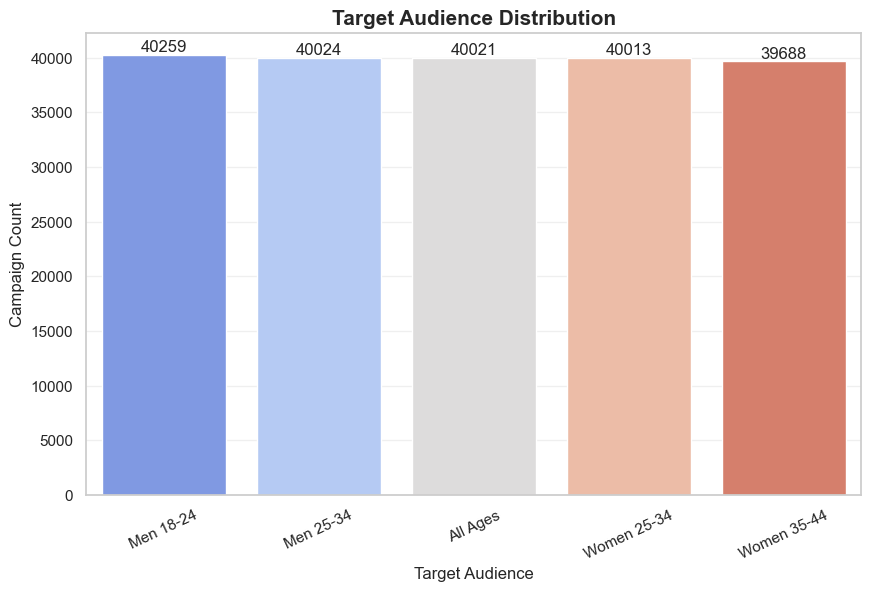


📌 Business Insight:
Some audience groups receive more campaign focus than others.

💡 Recommendation:
Increase investment in audience groups with strong business outcomes.


In [ ]:
# ==========================================
# Target Audience Analysis
# ==========================================

target_col = next((c for c in df_fe.columns if "target" in c.lower()), None)

if target_col:

    plt.figure(figsize=(10,6))

    counts = df_fe[target_col].value_counts()

    ax = sns.barplot(
        x=counts.index,
        y=counts.values,
        palette="coolwarm"
    )

    plt.title("Target Audience Distribution", fontsize=15, weight="bold")
    plt.xlabel("Target Audience")
    plt.ylabel("Campaign Count")
    plt.xticks(rotation=25)
    plt.grid(axis="y", alpha=0.3)

    for p in ax.patches:
        ax.annotate(
            int(p.get_height()),
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom"
        )

    plt.show()

    print("\n📌 Business Insight:")
    print("Some audience groups receive more campaign focus than others.")

    print("\n💡 Recommendation:")
    print("Increase investment in audience groups with strong business outcomes.")

else:
    print("Target Audience column not found.")

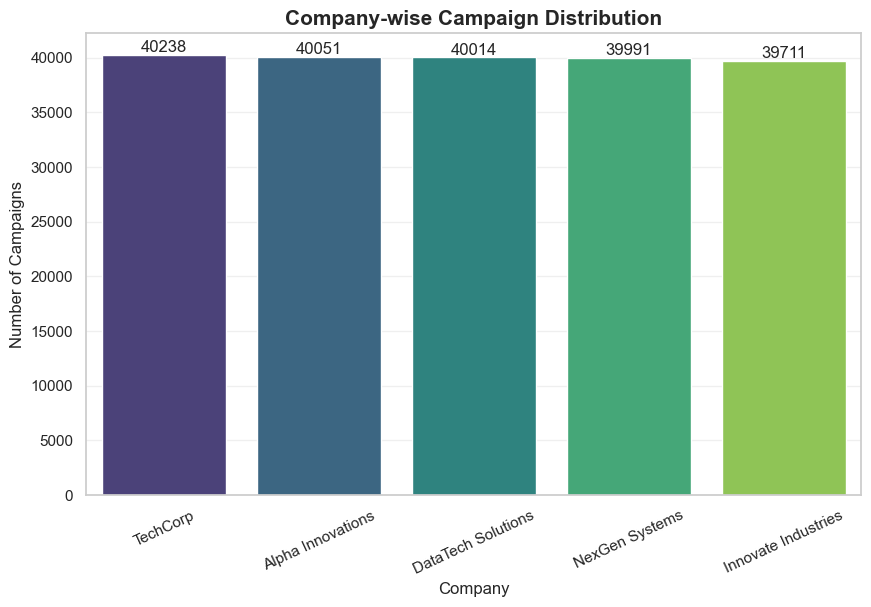


📌 Business Insight:
This chart compares campaign volume across companies.

💡 Recommendation:
Benchmark campaign strategies used by companies with stronger performance.


In [ ]:
# ==========================================
# Company Analysis
# ==========================================

company_col = next((c for c in df_fe.columns if "company" in c.lower()), None)

if company_col:

    plt.figure(figsize=(10,6))

    counts = df_fe[company_col].value_counts()

    ax = sns.barplot(
        x=counts.index,
        y=counts.values,
        palette="viridis"
    )

    plt.title("Company-wise Campaign Distribution", fontsize=15, weight="bold")
    plt.xlabel("Company")
    plt.ylabel("Number of Campaigns")
    plt.xticks(rotation=25)
    plt.grid(axis="y", alpha=0.3)

    for p in ax.patches:
        ax.annotate(
            int(p.get_height()),
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom"
        )

    plt.show()

    print("\n📌 Business Insight:")
    print("This chart compares campaign volume across companies.")

    print("\n💡 Recommendation:")
    print("Benchmark campaign strategies used by companies with stronger performance.")

else:
    print("Company column not found.")

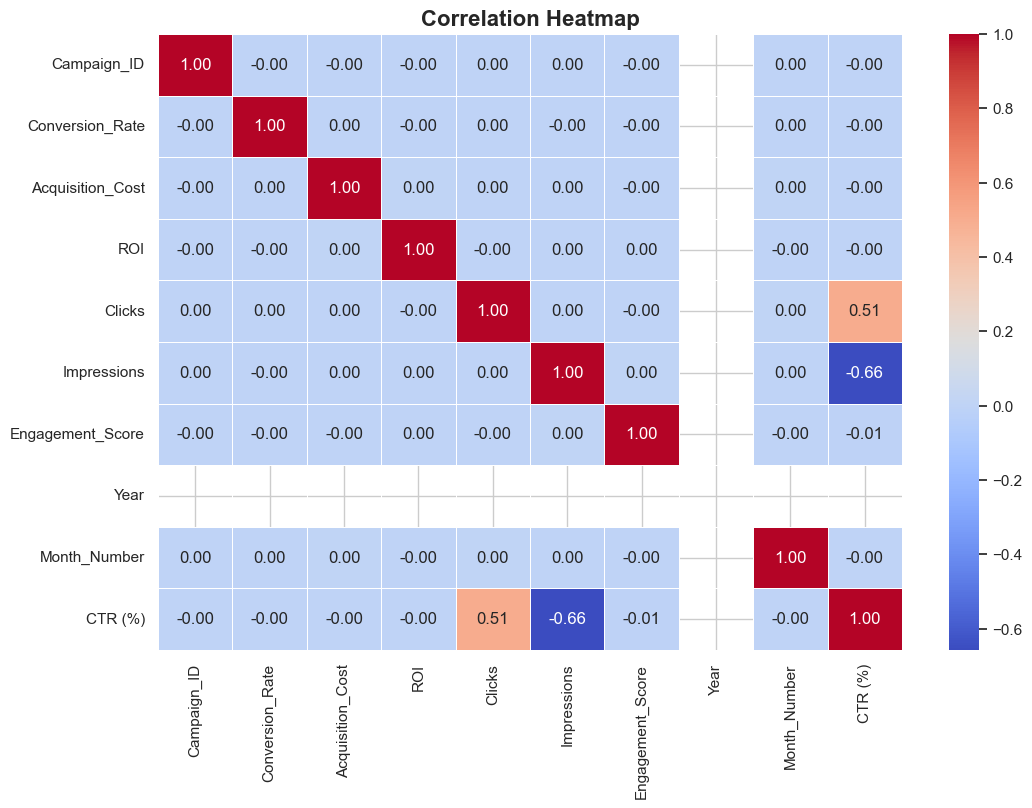

📌 Business Insight:
Highly correlated variables indicate strong relationships.

💡 Recommendation:
Focus on variables strongly correlated with ROI and Conversion Rate.


In [ ]:
# ==========================================
# Correlation Heatmap
# ==========================================

numeric_df = df_fe.select_dtypes(include=np.number)

if numeric_df.shape[1] > 1:

    plt.figure(figsize=(12,8))

    sns.heatmap(
        numeric_df.corr(),
        annot=True,
        cmap="coolwarm",
        linewidths=0.5,
        fmt=".2f"
    )

    plt.title("Correlation Heatmap", fontsize=16, weight="bold")
    plt.show()

    print("📌 Business Insight:")
    print("Highly correlated variables indicate strong relationships.")

    print("\n💡 Recommendation:")
    print("Focus on variables strongly correlated with ROI and Conversion Rate.")

else:
    print("Not enough numeric columns.")

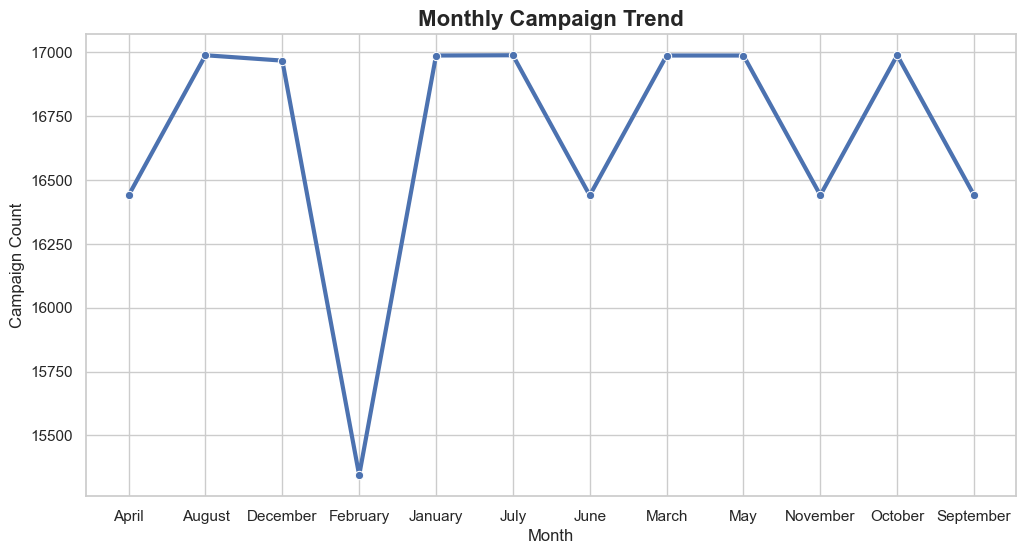

📌 Business Insight:
Campaign activity varies across months.

💡 Recommendation:
Increase budget during peak-performing months.


In [ ]:
# ==========================================
# Monthly Campaign Trend
# ==========================================

if "Month" in df_fe.columns:

    monthly = df_fe["Month"].value_counts().sort_index()

    plt.figure(figsize=(12,6))

    ax = sns.lineplot(
        x=monthly.index,
        y=monthly.values,
        marker="o",
        linewidth=3
    )

    plt.title("Monthly Campaign Trend", fontsize=16, weight="bold")
    plt.xlabel("Month")
    plt.ylabel("Campaign Count")
    plt.grid(True)

    plt.show()

    print("📌 Business Insight:")
    print("Campaign activity varies across months.")

    print("\n💡 Recommendation:")
    print("Increase budget during peak-performing months.")

else:
    print("Month feature not available.")

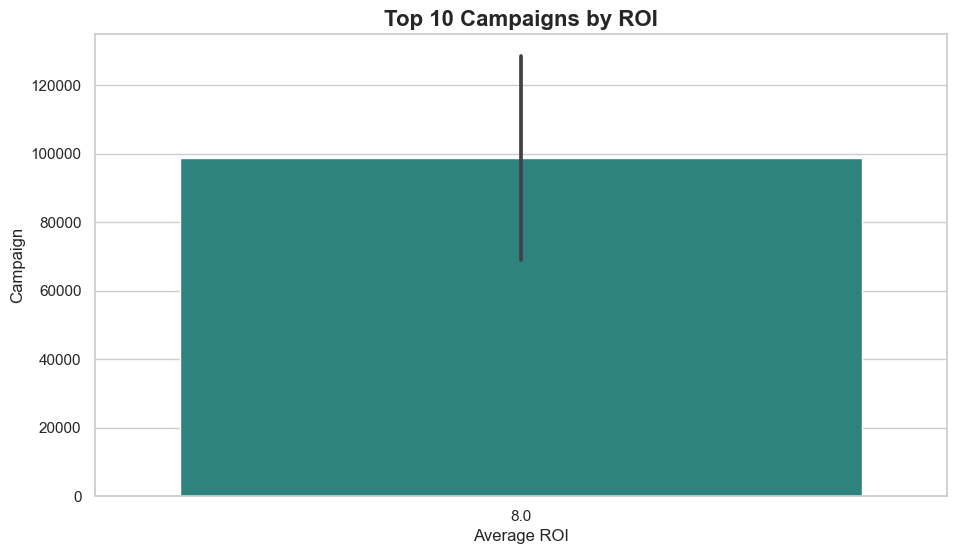

📌 Business Insight:
These campaigns generate the highest ROI.

💡 Recommendation:
Scale these campaigns for better business growth.


In [ ]:
# ==========================================
# Top Performing Campaigns
# ==========================================

campaign = next((c for c in df_fe.columns if "campaign" in c.lower()), None)
roi = next((c for c in df_fe.columns if c.lower()=="roi"), None)

if campaign and roi:

    top = df_fe.groupby(campaign)[roi].mean().sort_values(ascending=False).head(10)

    plt.figure(figsize=(11,6))

    ax = sns.barplot(
        x=top.values,
        y=top.index,
        palette="viridis"
    )

    plt.title("Top 10 Campaigns by ROI", fontsize=16, weight="bold")
    plt.xlabel("Average ROI")
    plt.ylabel("Campaign")

    plt.show()

    print("📌 Business Insight:")
    print("These campaigns generate the highest ROI.")

    print("\n💡 Recommendation:")
    print("Scale these campaigns for better business growth.")

else:
    print("Campaign or ROI column missing.")

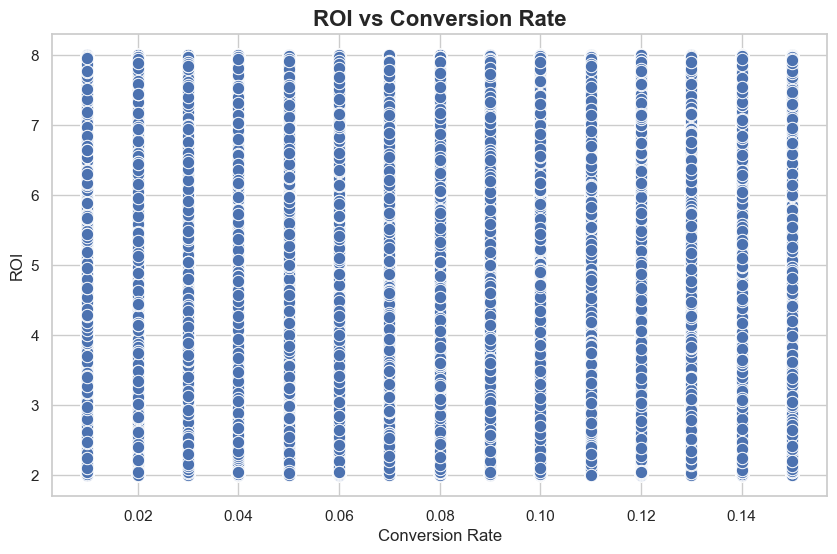

📌 Business Insight:
Shows the relationship between conversion and ROI.

💡 Recommendation:
Improve conversion to maximize ROI.


In [ ]:
# ==========================================
# ROI vs Conversion Rate
# ==========================================

roi = next((c for c in df_fe.columns if c.lower()=="roi"), None)
conv = next((c for c in df_fe.columns if "conversion" in c.lower()), None)

if roi and conv:

    plt.figure(figsize=(10,6))

    sns.scatterplot(
        data=df_fe,
        x=conv,
        y=roi,
        s=80
    )

    plt.title("ROI vs Conversion Rate", fontsize=16, weight="bold")
    plt.xlabel("Conversion Rate")
    plt.ylabel("ROI")
    plt.grid(True)

    plt.show()

    print("📌 Business Insight:")
    print("Shows the relationship between conversion and ROI.")

    print("\n💡 Recommendation:")
    print("Improve conversion to maximize ROI.")

else:
    print("Required columns not found.")

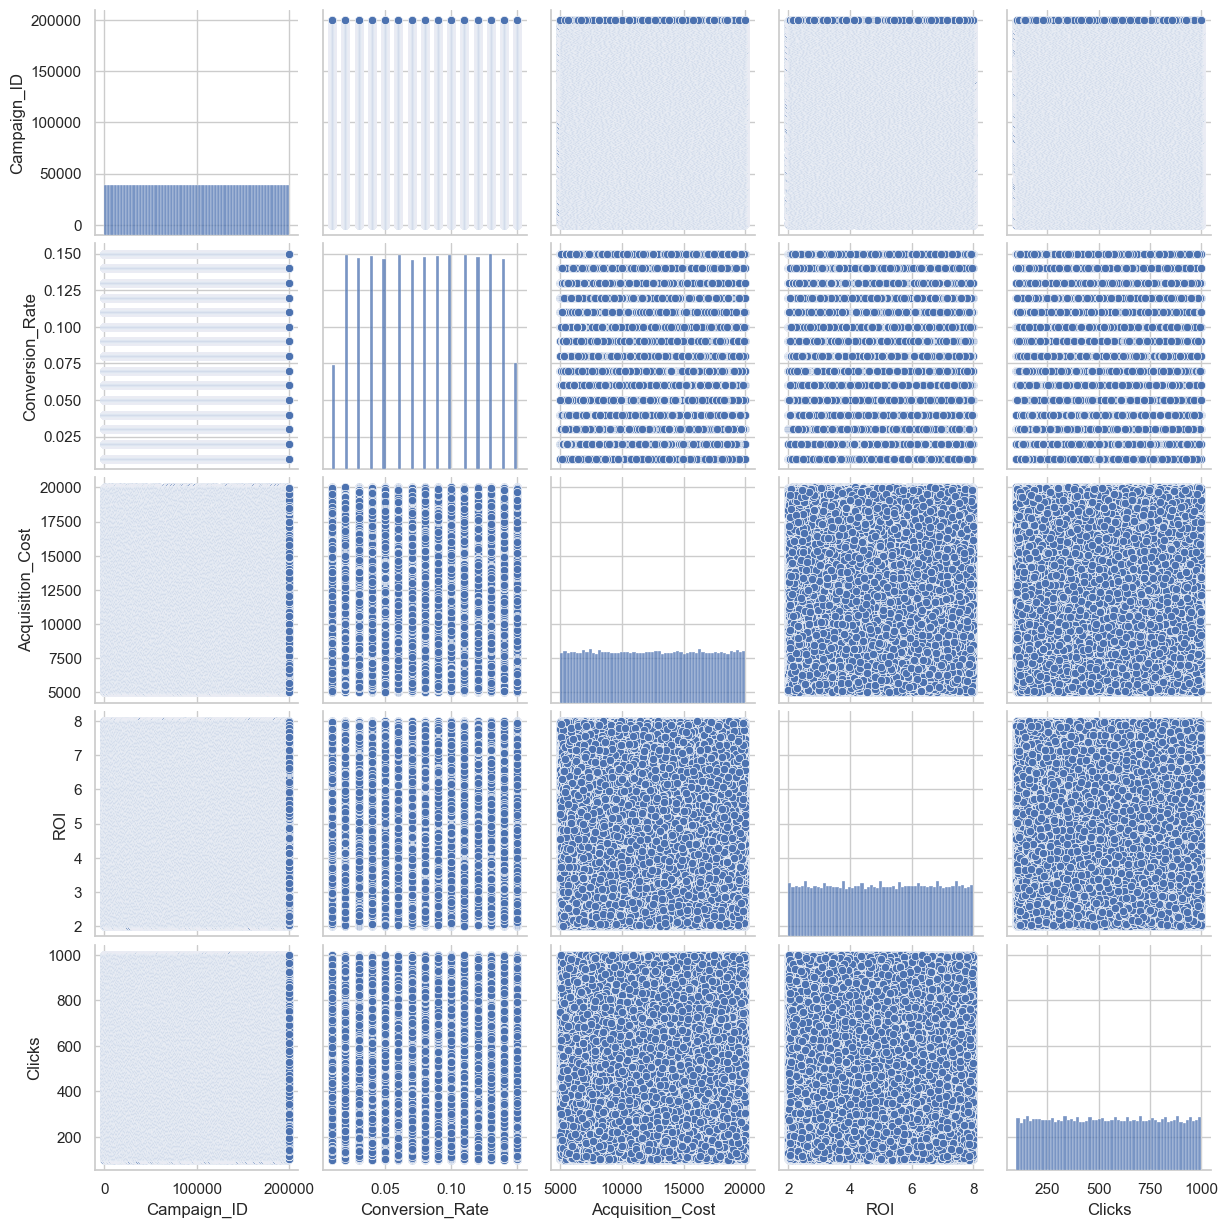

📌 Business Insight:
Visualizes relationships among important numerical variables.

💡 Recommendation:
Use strong correlations for predictive modeling.


In [ ]:
# ==========================================
# Pairplot
# ==========================================

cols = []

for col in df_fe.select_dtypes(include=np.number).columns:
    cols.append(col)

cols = cols[:5]

if len(cols) >= 2:

    sns.pairplot(df_fe[cols])

    plt.show()

    print("📌 Business Insight:")
    print("Visualizes relationships among important numerical variables.")

    print("\n💡 Recommendation:")
    print("Use strong correlations for predictive modeling.")

else:
    print("Not enough numeric columns.")

In [ ]:
# ==========================================
# KPI Summary
# ==========================================

print("="*60)
print("MARKETING KPI DASHBOARD")
print("="*60)

print(f"Total Campaigns : {len(df_fe)}")

if "ROI" in df_fe.columns:
    print(f"Average ROI : {df_fe['ROI'].mean():.2f}")

conv = next((c for c in df_fe.columns if "conversion" in c.lower()), None)
if conv:
    print(f"Average Conversion Rate : {df_fe[conv].mean():.2f}")

ctr = next((c for c in df_fe.columns if "CTR" in c), None)
if ctr:
    print(f"Average CTR : {df_fe[ctr].mean():.2f}%")

cost = next((c for c in df_fe.columns if "acquisition" in c.lower()), None)
if cost:
    print(f"Average Acquisition Cost : {df_fe[cost].mean():.2f}")

eng = next((c for c in df_fe.columns if "engagement" in c.lower()), None)
if eng:
    print(f"Average Engagement Score : {df_fe[eng].mean():.2f}")

print("="*60)

MARKETING KPI DASHBOARD
Total Campaigns : 200005
Average ROI : 5.00
Average Conversion Rate : 0.08
Average CTR : 14.04%
Average Acquisition Cost : 12504.44
Average Engagement Score : 5.49


In [15]:
df["Acquisition_Cost"] = (
    df["Acquisition_Cost"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [16]:
df.to_csv("cleaned_marketing_campaign.csv", index=False)

In [17]:
df.to_csv(
    r"C:\Users\admin\Downloads\OneDrive\python\Marketing-Campaign-Performance\data\cleaned_marketing_campaign.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [19]:
# Convert the Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=False, errors="coerce")

# Convert to MySQL date format (YYYY-MM-DD)
df["Date"] = df["Date"].dt.strftime("%Y-%m-%d")

# Save cleaned dataset
df.to_csv("cleaned_marketing_campaign.csv", index=False)

print("Date format fixed and dataset saved successfully.")

Date format fixed and dataset saved successfully.


In [20]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(df["Date"].isnull().sum())

0


In [21]:
print(df.dtypes)

Campaign_ID                  int64
Company                     object
Campaign_Type               object
Target_Audience             object
Duration                    object
Channel_Used                object
Conversion_Rate            float64
Acquisition_Cost           float64
ROI                        float64
Location                    object
Date                datetime64[ns]
Clicks                       int64
Impressions                  int64
Engagement_Score             int64
Customer_Segment            object
dtype: object


In [22]:
sample_df = df.head(5000)

sample_df.to_csv(
    "sample_marketing_campaign.csv",
    index=False,
    encoding="utf-8",
    date_format="%Y-%m-%d"
)

print("Sample saved.")

Sample saved.
